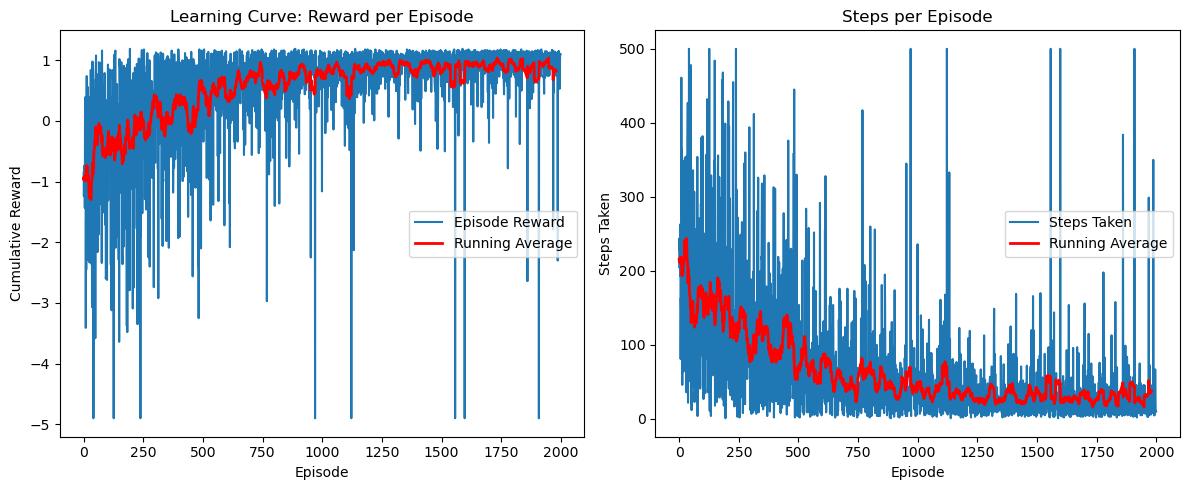

/var/folders/tl/ckypw7h13vx2smz3g7pd3l340000gn/T/ipykernel_46768/3844699166.py:120: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  p.set_data(traj[frame,i,0], traj[frame,i,1])


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import HTML
from matplotlib import animation

# ===================== Parameters =====================
GRID_SIZE = 8
N_AGENTS = 2
ACTIONS = np.array([[0,1],[1,0],[0,-1],[-1,0],[0,0]])  # R, D, L, U, Stay
N_ACTIONS = len(ACTIONS)

MAX_EPISODES = 2000
MAX_STEPS = 500
ALPHA_START, ALPHA_END = 0.5, 0.05
EPSILON_START, EPSILON_END = 0.6, 0.05
GAMMA = 0.95

STEP_PENALTY = -0.01
ARRIVAL_BONUS = 0.2
TEAM_SUCCESS_BONUS = 1.0
COLLISION_PENALTY = -0.2   # 🔴 New: penalty for collision

np.random.seed(0)

# Environment
class GridEnv:
    def __init__(self, grid_size, n_agents):
        self.grid_size = grid_size
        self.n_agents = n_agents

    def reset(self):
        self.agents = self._sample_distinct(self.n_agents)
        self.targets = self._sample_distinct(self.n_agents)
        self.on_target_flags = [False]*self.n_agents
        return self.agents.copy(), self.targets.copy()

    def _sample_distinct(self, k):
        idxs = np.random.choice(self.grid_size**2, size=k, replace=False)
        return np.c_[idxs // self.grid_size, idxs % self.grid_size]

    def step(self, actions):
        # Prevent agents who are on target from moving
        move_actions = actions.copy()
        for i, flag in enumerate(self.on_target_flags):
            if flag:
                move_actions[i] = N_ACTIONS-1  # Stay

        proposed = np.clip(self.agents + ACTIONS[move_actions], 0, self.grid_size-1)
        new_positions = proposed.copy()

        # vertex conflicts
        for cell, idxs in self._group_by(proposed).items():
            if len(idxs) > 1:
                for i in idxs:
                    new_positions[i] = self.agents[i]

        # edge conflicts
        for i in range(self.n_agents):
            for j in range(i+1, self.n_agents):
                if np.all(proposed[i] == self.agents[j]) and np.all(proposed[j] == self.agents[i]):
                    new_positions[i] = self.agents[i]
                    new_positions[j] = self.agents[j]

        self.agents = new_positions
        done = np.all(self.agents == self.targets)
        return self.agents.copy(), done

    def _group_by(self, arr):
        d = {}
        for i, cell in enumerate(map(tuple, arr)):
            d.setdefault(cell, []).append(i)
        return d

# Agent
class QAgent:
    def __init__(self, alpha, gamma, epsilon):
        self.Q = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def state_key(self, agent_pos, target_pos):
        return (int(agent_pos[0]), int(agent_pos[1]), int(target_pos[0]), int(target_pos[1]))

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(N_ACTIONS)
        qvals = np.array([self.Q[(state,a)] for a in range(N_ACTIONS)])
        maxq = np.max(qvals)
        return int(np.random.choice(np.flatnonzero(qvals == maxq)))

    def update(self, s, a, r, ns, done):
        qnext = [self.Q[(ns, ap)] for ap in range(N_ACTIONS)]
        target = r + (0 if done else self.gamma * np.max(qnext))
        self.Q[(s,a)] += self.alpha * (target - self.Q[(s,a)])

# HTML Animation
def animate_traj_html(traj, targets, size):
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, size-0.5)
    ax.set_ylim(-0.5, size-0.5)
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.grid(True)

    n_agents = traj.shape[1]
    colors = ['r','b','g','y','m','c']
    points = [ax.plot([], [], 'o', color=colors[i])[0] for i in range(n_agents)]
    target_pts = [ax.plot(targets[i,0], targets[i,1], 'x', color=colors[i], markersize=10)[0] 
                  for i in range(n_agents)]

    def init():
        for p in points:
            p.set_data([], [])
        return points
    
    def update(frame):
        for i, p in enumerate(points):
            p.set_data(traj[frame,i,0], traj[frame,i,1])
        return points

    ani = animation.FuncAnimation(fig, update, frames=len(traj),
                                  init_func=init, blit=True, interval=300)
    plt.close(fig)
    return HTML(ani.to_jshtml())

# Training
env = GridEnv(GRID_SIZE, N_AGENTS)
agents = [QAgent(ALPHA_START, GAMMA, EPSILON_START) for _ in range(N_AGENTS)]

rewards_history = []
steps_history = []

for ep in range(MAX_EPISODES):
    states, targets = env.reset()
    ep_return, done = 0, False

    # Anneal epsilon & alpha
    eps = EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-ep / (0.3*MAX_EPISODES))
    alpha = ALPHA_END + (ALPHA_START - ALPHA_END) * np.exp(-ep / (0.8*MAX_EPISODES))
    for ag in agents:
        ag.epsilon, ag.alpha = eps, alpha

    traj = [states.copy()]

    for t in range(MAX_STEPS):
        actions = []
        states_keys = []
        for i, ag in enumerate(agents):
            s_key = ag.state_key(states[i], targets[i])
            states_keys.append(s_key)
            # Freeze agent if it reached target
            if env.on_target_flags[i]:
                actions.append(N_ACTIONS-1)  # Stay
            else:
                actions.append(ag.act(s_key))

        next_states, done = env.step(actions)

        # --- Reward calculation ---
        rewards = [STEP_PENALTY for _ in range(N_AGENTS)]

        # Arrival bonus
        for i in range(N_AGENTS):
            if np.all(next_states[i] == targets[i]) and not env.on_target_flags[i]:
                rewards[i] += ARRIVAL_BONUS
                env.on_target_flags[i] = True

        # Collision penalty
        pos_groups = env._group_by(next_states)
        for cell, idxs in pos_groups.items():
            if len(idxs) > 1:  # collision
                for i in idxs:
                    rewards[i] += COLLISION_PENALTY

        # Team success bonus
        if done:
            for i in range(N_AGENTS):
                rewards[i] += TEAM_SUCCESS_BONUS

        # Q-learning update
        for i, ag in enumerate(agents):
            ns_key = ag.state_key(next_states[i], targets[i])
            ag.update(states_keys[i], actions[i], rewards[i], ns_key, done)

        ep_return += np.mean(rewards)
        states = next_states
        traj.append(states.copy())

        if done:
            break

    rewards_history.append(ep_return)
    steps_history.append(len(traj)-1)

# Plot Learning Curves
def moving_average(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))

# Reward plot
plt.subplot(1,2,1)
plt.plot(rewards_history, label='Episode Reward')
plt.plot(range(len(rewards_history) - 19), moving_average(rewards_history), 'r', linewidth=2, label='Running Average')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('Learning Curve: Reward per Episode')
plt.legend()

# Steps plot
plt.subplot(1,2,2)
plt.plot(steps_history, label='Steps Taken')
plt.plot(range(len(steps_history) - 19), moving_average(steps_history), 'r', linewidth=2, label='Running Average')
plt.xlabel('Episode')
plt.ylabel('Steps Taken')
plt.title('Steps per Episode')
plt.legend()

plt.tight_layout()
plt.show()

# Animate Last Trajectory
traj = np.array(traj)
animate_traj_html(traj, targets, GRID_SIZE)

Training with 1 agents...
Training with 2 agents...
Training with 3 agents...
Training with 4 agents...
Training with 5 agents...
Training with 6 agents...
Training with 7 agents...
Training with 8 agents...
Training with 9 agents...
Training with 10 agents...


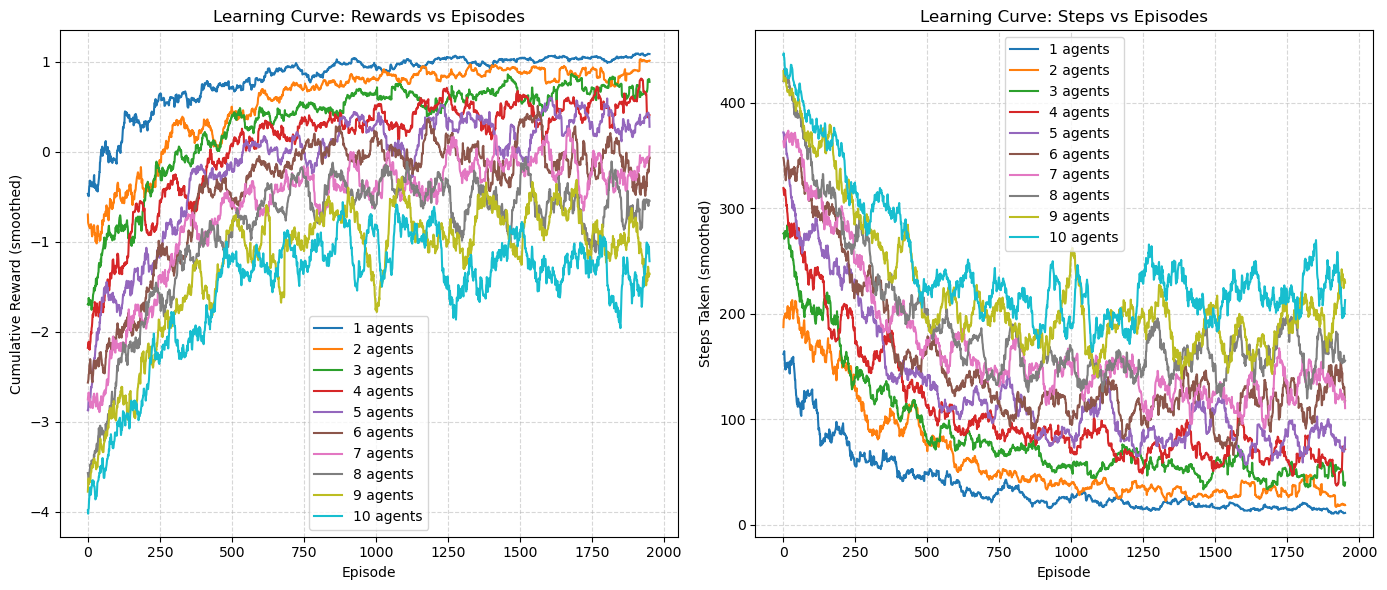

In [11]:
# Training Function
def train_multi_agent(n_agents, episodes=MAX_EPISODES):
    env = GridEnv(GRID_SIZE, n_agents)
    agents = [QAgent(ALPHA_START, GAMMA, EPSILON_START) for _ in range(n_agents)]

    rewards_history, steps_history = [], []

    for ep in range(episodes):
        states, targets = env.reset()
        ep_return, done = 0, False

        # Anneal epsilon & alpha
        eps = EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-ep / (0.3*episodes))
        alpha = ALPHA_END + (ALPHA_START - ALPHA_END) * np.exp(-ep / (0.8*episodes))
        for ag in agents:
            ag.epsilon, ag.alpha = eps, alpha

        for t in range(MAX_STEPS):
            actions, states_keys = [], []
            for i, ag in enumerate(agents):
                s_key = ag.state_key(states[i], targets[i])
                states_keys.append(s_key)
                if env.on_target_flags[i]:
                    actions.append(N_ACTIONS-1)  # Stay
                else:
                    actions.append(ag.act(s_key))

            next_states, done = env.step(actions)

            # --- Reward calculation ---
            rewards = [STEP_PENALTY for _ in range(n_agents)]

            # Arrival bonus
            for i in range(n_agents):
                if np.all(next_states[i] == targets[i]) and not env.on_target_flags[i]:
                    rewards[i] += ARRIVAL_BONUS
                    env.on_target_flags[i] = True

            # Collision penalty
            pos_groups = env._group_by(next_states)
            for cell, idxs in pos_groups.items():
                if len(idxs) > 1:
                    for i in idxs:
                        rewards[i] += COLLISION_PENALTY

            # Team success bonus
            if done:
                for i in range(n_agents):
                    rewards[i] += TEAM_SUCCESS_BONUS

            # Q-learning update
            for i, ag in enumerate(agents):
                ns_key = ag.state_key(next_states[i], targets[i])
                ag.update(states_keys[i], actions[i], rewards[i], ns_key, done)

            ep_return += np.mean(rewards)
            states = next_states

            if done:
                break

        rewards_history.append(ep_return)
        steps_history.append(t+1)

    return rewards_history, steps_history

# ===================== Compare Agent Numbers =====================
agent_counts = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = {}

for n in agent_counts:
    print(f"Training with {n} agents...")
    rewards, steps = train_multi_agent(n)
    results[n] = (rewards, steps)

# ===================== Plot Learning Curves =====================
def moving_average(x, window=50):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(14,6))

# Reward plot
plt.subplot(1,2,1)
for n in agent_counts:
    rewards = results[n][0]
    plt.plot(moving_average(rewards), label=f'{n} agents')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward (smoothed)')
plt.title('Learning Curve: Rewards vs Episodes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Steps plot
plt.subplot(1,2,2)
for n in agent_counts:
    steps = results[n][1]
    plt.plot(moving_average(steps), label=f'{n} agents')
plt.xlabel('Episode')
plt.ylabel('Steps Taken (smoothed)')
plt.title('Learning Curve: Steps vs Episodes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()